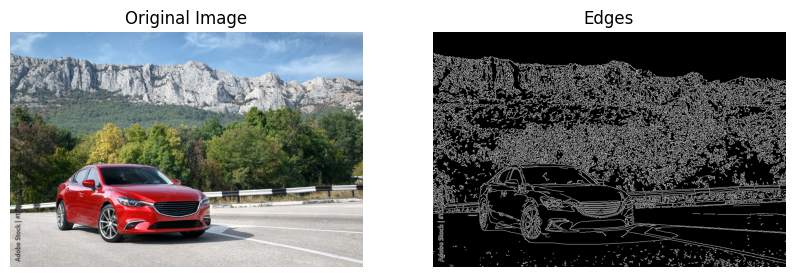

In [16]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("image.jpg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


edges = cv2.Canny(gray, 100, 200)


plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Edges")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.show()

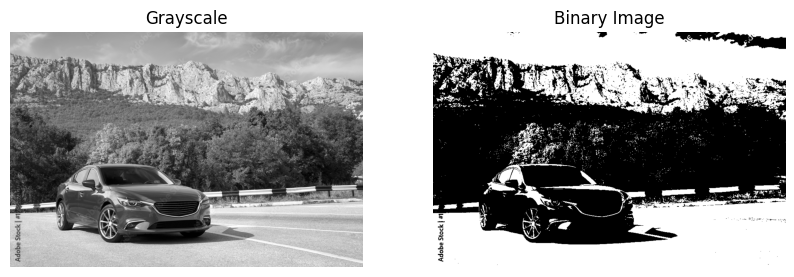

In [18]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("image.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Grayscale")
plt.imshow(gray, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Binary Image")
plt.imshow(thresh, cmap="gray")
plt.axis("off")

plt.show()

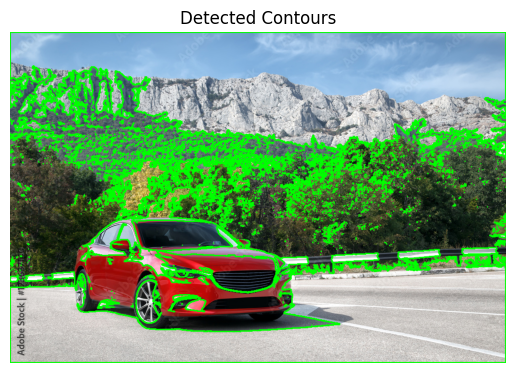

In [20]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("image.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)


cv2.drawContours(img_rgb, contours, -1, (0,255,0), 2)

plt.imshow(img_rgb)
plt.title("Detected Contours")
plt.axis("off")
plt.show()

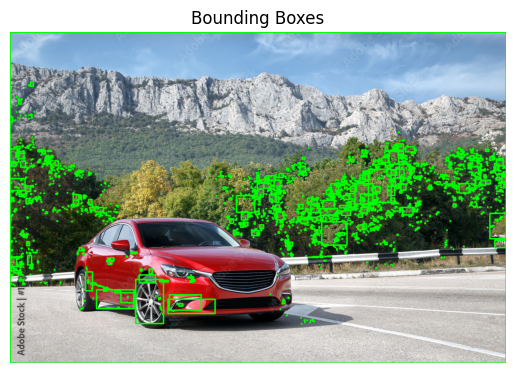

In [21]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("image.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, thresh = cv2.threshold(gray,100,255,cv2.THRESH_BINARY)

contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

for contour in contours:
    
    x,y,w,h = cv2.boundingRect(contour)

    cv2.rectangle(img_rgb,(x,y),(x+w,y+h),(0,255,0),2)

plt.imshow(img_rgb)
plt.title("Bounding Boxes")
plt.axis("off")
plt.show()

In [15]:
import cv2

img = cv2.imread("image2.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, thresh = cv2.threshold(gray,200,255,cv2.THRESH_BINARY)

contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

for contour in contours:

    peri = cv2.arcLength(contour, True)

    approx = cv2.approxPolyDP(contour, 0.04 * peri, True)

    x, y, w, h = cv2.boundingRect(contour)

    shape = "Unknown"

    if len(approx) == 3:
        shape = "Triangle"

    elif len(approx) == 4:
        shape = "Rectangle"

    elif len(approx) > 6:
        shape = "Circle"

    cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)

    cv2.putText(img, shape, (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,(0,255,0),2)

cv2.imshow("Shape Detection", img)

cv2.waitKey(0)
cv2.destroyAllWindows()